# Sztuczne Sieci Neuronowe (ANN)

In [4]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import numpy as np
import matplotlib.pyplot as plt

In [6]:
def f_plt(hist,tp='accuracy'):
    plt.plot(hist.history[tp], label=f'train {tp}')
    if f'val_{tp}' in hist.history:
        plt.plot(hist.history['val_accuracy'], label='val acc')
    plt.title(tp.capitalize())
    plt.xlabel('Epoka')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    plt.show()

early_stop = EarlyStopping(
    monitor='loss',           
    patience=20,              
    min_delta=0.001,          
    mode='min',
    verbose=1,
    restore_best_weights=True
)


# model.fit(X, y, epochs=1000, callbacks=[early_stop], verbose=0)

## Tabele prawdy (przypomnienie) dla funkcji NOT, AND, OR, XOR
### Tabela prawdy – funkcja NOT

| A | NOT A |
|---|-------|
| 0 |   1   |
| 1 |   0   |

### Dane treningowe dla funkcji AND

| A | B | A AND B |
|---|---|---------|
| 0 | 0 |    0    |
| 0 | 1 |    0    |
| 1 | 0 |    0    |
| 1 | 1 |    1    |

### Tabela prawdy – funkcja OR

| A | B | A OR B |
|---|---|--------|
| 0 | 0 |   0    |
| 0 | 1 |   1    |
| 1 | 0 |   1    |
| 1 | 1 |   1    |

### Tabela prawdy – funkcja XOR

| A | B | A XOR B |
|---|---|---------|
| 0 | 0 |    0    |
| 0 | 1 |    1    |
| 1 | 0 |    1    |
| 1 | 1 |    0    |

In [5]:
test = "XOR"

test = test.lower()

if test == 'not':
    X = np.array([[0], [1]], dtype=np.float32)
    y = np.array([[1], [0]], dtype=np.float32)
elif test == 'and':
    X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=np.float32)
    y = np.array([[0], [0], [0], [1]], dtype=np.float32)
elif test == 'or':
    X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=np.float32)
    y = np.array([[0], [0], [0], [1]], dtype=np.float32)
elif test == 'xor':
    X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=np.float32)
    y = np.array([[0], [1], [1], [0]], dtype=np.float32)


### Model z jednym neuronem (perceptron: jedno wejście -> jedno wyjście)

In [2]:
model = Sequential()
model.add(Dense(units=1, activation='sigmoid', input_shape=(1,), use_bias=True))

### Model z jednym neuronem (perceptron: dwa wejścia -> jedno wyjście)

In [9]:
model = Sequential()
model.add(Dense(units=1, activation='sigmoid', input_shape=(2,), use_bias=True))

In [14]:
model = Sequential()
model.add(Dense(units=3, activation='sigmoid', input_shape=(2,), use_bias=True))
model.add(Dense(units=1, activation='sigmoid', use_bias=True))


Testy modelu:
1/1 [==============================] - 0s 82ms/step
Wejście: [0. 0.] => Przewidywane wyjście: 0.0000
Wejście: [0. 1.] => Przewidywane wyjście: 1.0000
Wejście: [1. 0.] => Przewidywane wyjście: 1.0000
Wejście: [1. 1.] => Przewidywane wyjście: 0.0000
1/1 [==============================] - 0s 185ms/step - loss: 0.3697 - accuracy: 1.0000
Dokładność na zbiorze testowym: 1.00, strata: 0.3697405755519867


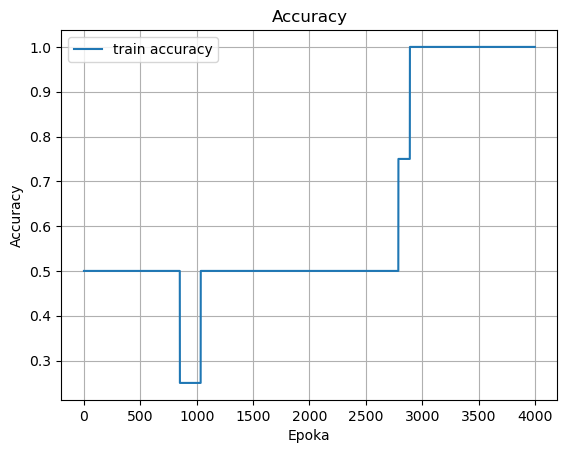

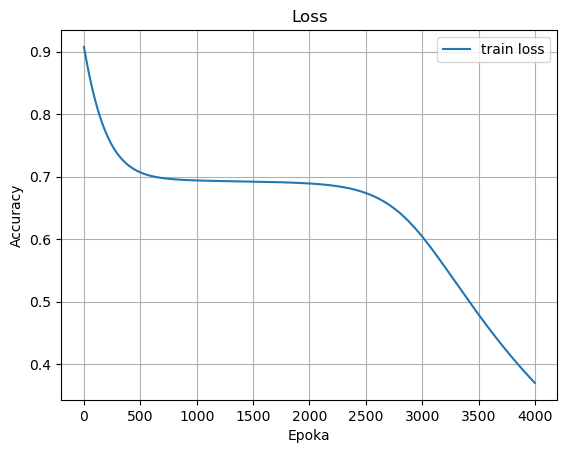

In [15]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history = model.fit(X, y, epochs=4000, verbose=0)

print("\nTesty modelu:")
predictions = model.predict(X)
binary_predictions = (predictions >= 0.5).astype(int)

for i, pred in enumerate(binary_predictions):
    print(f"Wejście: {X[i]} => Przewidywane wyjście: {pred[0]:.4f}")

loss, accuracy = model.evaluate(X, y)
print(f'Dokładność na zbiorze testowym: {accuracy:.2f}, strata: {loss}')

f_plt(history)
f_plt(history,'loss')


### Klasyfikacja za pomocą ANN

In [16]:
iris = load_iris()
X = iris.data
y = iris.target

encoder = LabelBinarizer()
y_encoded = encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

1/1 [==============================] - 0s 27ms/step - loss: 0.3667 - accuracy: 0.9000
Dokładność na zbiorze testowym: 0.90


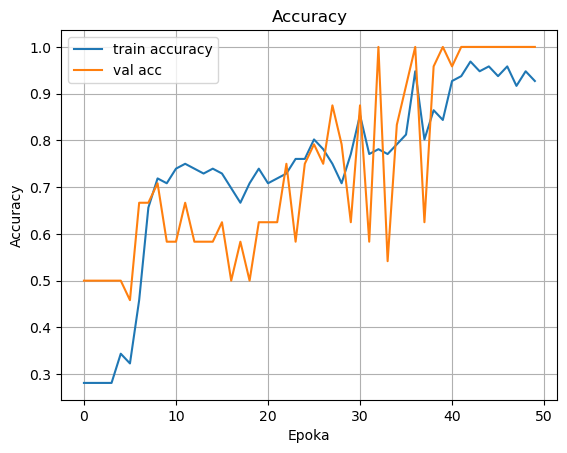

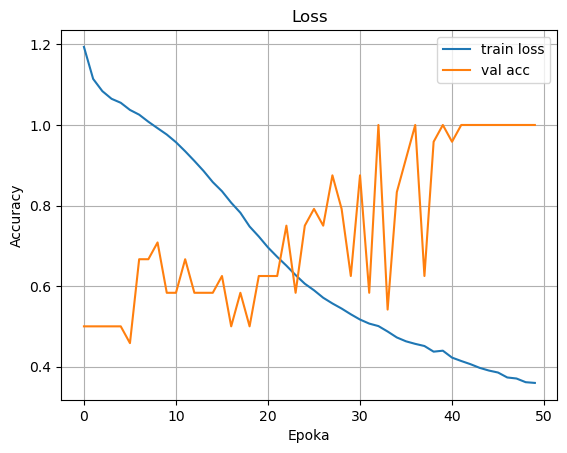

1/1 [==============================] - 0s 56ms/step - loss: 0.3667 - accuracy: 0.9000
Dokładność na zbiorze testowym: 0.90
1/1 [==============================] - 0s 126ms/step


In [17]:
model = Sequential()
model.add(Dense(10, input_shape=(4,), activation='relu'))
model.add(Dense(10, activation='relu'))
model.add(Dense(3, activation='softmax'))

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=5,
    verbose=0,
    validation_split=0.2
)

loss, accuracy = model.evaluate(X_test, y_test)
print(f'Dokładność na zbiorze testowym: {accuracy:.2f}')

f_plt(history)
f_plt(history,'loss')

loss, accuracy = model.evaluate(X_test, y_test)
print(f'Dokładność na zbiorze testowym: {accuracy:.2f}')


y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

In [18]:
# Przykładowy wektor cech: [długość działki kielicha, szerokość działki, długość płatka, szerokość płatka]
example = np.array([[6.1, 3.9, 4.7, 1.4]], dtype=np.float32)

probs = model.predict(example)

predicted_class = np.argmax(probs)

class_names = ['setosa', 'versicolor', 'virginica']
print(f"Gatunek przewidywany: {class_names[predicted_class]} {probs}")

1/1 [==============================] - 0s 26ms/step
Gatunek przewidywany: versicolor [[0.0171049  0.62610763 0.3567875 ]]
